In [1]:
%%html
<style>
h1,h2,h3 {
    text-align: center;
}

.term {
    text-align: center;
    margin-top: 1em;
    margin-bottom: 1em;
}

.organizers {
    text-align: center;
    margin-left: 20%;
    margin-right: 20%;
    margin-bottom: 1em;
}

.presenter {
    text-decoration: underline;
}
</style>


<div style="font-size: 3vw;"> Python Programming for Machine Learning </div>

<div class="term">Summer Term 2026</div>

<div class="organizers">
    <span class="presenter">Johannes Maeß</span>
</div>

<center><img src='images/python-logo-only.svg' width=250> </center>

# Autoregressive Language Modeling (with a small Multilayer Perceptrons)

## Motivation and Outline

- **Task of the lecture**: Build a character-level language model using a Multi-Layer Perceptron (MLP), train and evaluate it.
- **Focus**: Implementing the forward and backward computation of a model manually.

<div style="text-align: center;">
    <img src="images/char_level_lm.png" alt="character-level language model" style="width: 800px;">
</div>


- **Language modeling's significance**: Recent AI advancements, applications in chatbots, virtual assistants, and content generation.
- **MLPs**: Foundational in neural networks, adept at capturing complex data patterns.

- Bridging theory with Python application enhances real-world ML skills.

## References

- Lecture is mainly built on the lecture ["Building makemore Part 2: MLP"](https://youtu.be/TCH_1BHY58I?feature=shared) of Andrej Karpathy.
- Andrej's lecture strongly follows the paper of [Bengio et al.](https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf). 
    - *Note*: This paper considers MLPs for word-level language models. 
- Additional books: "Deep Learning" by Goodfellow et al., "Python Machine Learning" by Raschka and Mirjalili.


## Follow-up material (optional self-learning)
Content by  Andrej Karpathys, the entire 'makemore' series, and specifically [Part 3 - Gradients & Activations](https://youtu.be/P6sfmUTpUmc?si=AT0-VdOK3ijGqANr) and [Part 4 - Implementing Backprop yourself](https://youtu.be/q8SA3rM6ckI?si=CfUt8j6bpVW7e2kT) are highly recommended ressources.

After getting to know Automatic Differentiation last week, the autoregressive model architecture this week, and implementing AD on a small scale in Assignment 4, you will be in the perfect spot to study through this, consolidate your learnings, and get a very deep understanding of neural network design.

# How to build a character-level language model using a MLP? – Task description

## Model architecture

<div style="text-align: center;">
<img src="images/diagram_nn.png" alt="Image Description" style="width: 900px;">
</div>

- Take the the $n$ previous characters ($c_{t-n+1}$, ..., $c_{t-2}$, $c_{t-1}$) to predict the next character $c_{t}$
- We define the window of $n$ previous characters as the **"context length"**. 


- The **Embedding layer** serves as our NN input layer for all $n$ embedded characters. 
    - Characters are embedded in a space of dimension $d$ by accessing the the lookup table $C \in \mathbb{R}^{27 \times d}$. 
        - In the beginning, this embedding is random
        - During the training of our MLP, we move these embeddings in the space so that characters that appear more often together in words are closer in this space.
    - It contains of $d \cdot n$ neurons.
    - We will denote the concatenated embedding vector as  $ \mathbf{e}=C(\mathbf{x}) \in \mathbb{R}^{d\cdot n}$.



- The **Hidden layer** consists of neurons, and the number of neurons `k` is a **hyper-parameter**, i.e., an adjustable design parameter.
    - We will see how to "tune" this parameter to get the best model architecture. 
    - **Note**: We are in a fully connected setting, meaning that every neuron in the embedding layer is connected to all the neurons in the hidden layer.
        - Thus, the parameters connecting the embedding to the hidden layer are: Weights $W^{(1)} \in \mathbb{R}^{k \times (d \cdot n)}$ and biases $b^{(1)} \in \mathbb{R}^{k}$
    -  In the figure, you see that the hidden layer is using `tanh` activation/non-linearity.
    -  Thus, after the hidden layer, we get the activations:
$$
z^{(1)} = \tanh\left(W^{(1)} \mathbf{e} + b^{(1)}\right)
$$


- The **Output layer** consists of $27$ neurons and is fully connected to the previous layer. 
  - The parameters connecting the hidden to the output layer are: Weights $W^{(2)} \in \mathbb{R}^{27 \times k}$ and biases $b^{(2)} \in \mathbb{R}^{27}$
  - The output layer first computes the logits, $z^{(2)} \in \mathbb{R}^{27}$ as follows:
    $$
    z^{(2)} = W^{(2)}z^{(1)} + b^{(2)}
    $$
  - Then, it uses the `softmax` function to convert logits to a probability distribution. 
      - For a vector $z$ with components $z_i$:
$$
\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{n} e^{z_j}}
$$
      - Properties
        - Range: (0, 1) for each component.
        - Sum of Outputs: The sum of all output probabilities is 1.

## Training objective

- During training of our language model we want to maximize the log-likelihood of the data.
$$
\max_{\theta}\mathcal{L}(\theta) = \max_{\theta} \sum_{i=1}^{N} \log P(y_i | \mathbf{e}_i, \theta) 
$$

- where:
    - $ \mathcal{L}(\theta) $ is the log-likelihood function,
    - $ \theta = (C, W^{(1)}, b^{(1)}, W^{(2)}, b^{(2)}) $ represents all the parameters of the model, including weights, biases, and the lookup table,
    - $ N $ is the number of samples in the dataset,
    - $ \mathbf{e}_i \in \mathbb{R}^{(d * n)}$ represents the input features for sample $ i $, i.e., the concatenated embeddings of the $n$ characters,
    - $ y_i \in \mathbb{R}$ represents the target output for sample $ i $, and
    - $ P(y_i | \mathbf{e}_i, \theta) $ is the probability of observing the target output $ y_i $ given the input features $ \mathbf{e}_i $ and the model parameters $ \theta $.

### We will optimize the log-likelihood by minimizing the cross-entroy loss and using backpropagation

$$ \text{CE}(\theta) = -\frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{C} y_{ij} \log(q_{ij}) $$

- where:
    - $ \text{CE}(\theta) $ is the cross-entropy loss function,
    - $ \theta $ represents all the parameters of the model,
    - $ N $ is the number of samples in the dataset,
    - $ C $ is the number of classes,
    - $ y_{ij} $ is the true probability of class $ j $ for sample $ i $ (one-hot encoded vector of the possible characters),
    - $ q_{ij} $ is the predicted probability of class $ j $ for sample $ i $ (output of softmax layer).
- ***Note**: The negative log-likelihood is equivalent to the cross-entropy loss when the true labels are represented as one-hot vectors.* 

##  Small detour: activation functions and their implications (optional)

In [2]:
### This cell is not shown in the lecture slides, 
### but creates the figures shown in the cell below.

import numpy as np
import matplotlib.pyplot as plt

# Define the functions
def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def plot_act_fun(x, y, label):
    fig = plt.figure(figsize=(5,5))
    plt.plot(x, y, label=label, color='blue' if label=='tanh' else 'red')
    plt.title(f'{label} function')
    plt.xlabel('x')
    plt.ylabel(f'{label}(x)')
    plt.grid(True)
    plt.legend() 
    return fig

# Generate input values
x = np.linspace(-10, 10, 400)

# Calculate the output values
y_tanh = tanh(x)
y_relu = relu(x)

# Plot tanh
fig = plot_act_fun(x, y_tanh, label='tanh')
fig.savefig('images/tanh_function_plot.png', dpi=300, bbox_inches='tight')
plt.close(fig)

# Plot relu
fig = plot_act_fun(x, y_relu, label='ReLU')
fig.savefig('images/relu_function_plot.png', dpi=300, bbox_inches='tight')
plt.close(fig)

<div style="text-align: center;">
  <img src="images/tanh_function_plot.png" alt="Image 1" style="width: 30%; margin-right: 0px; float:left;">
  <img src="images/relu_function_plot.png" alt="Image 2" style="width: 30%; margin-left: 0px; float: left;">
</div>




| **Activation Function** | **tanh (Hyperbolic Tangent)** | **ReLU (Rectified Linear Unit)** |
|-------------------------|-------------------------------|-----------------------------------|
| **Range**               | -1 to 1                       | 0 to ∞ (or -∞ to ∞ with variants) |
| **Formula**             | $\text{tanh}(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$ | $\text{ReLU}(x) = \max(0, x)$  |
| **Characteristics**     | - Smooth and differentiable. <br> - Zero-centered: outputs range from -1 to 1, making optimization easier. <br> - Gradually saturates for large positive or negative inputs, leading to vanishing gradients. | - Simple and efficient. <br> - Non-saturating: does not saturate for large positive values, helping to avoid the vanishing gradient problem. |
| **Pros**                | - Good for handling inputs with strong negative values. <br> - Helps with centering the data, which can make training faster. | - Computationally efficient: requires only a threshold operation. <br> - Sparse activation: many neurons output zero, making the network efficient. <br> - Helps with faster convergence. |
| **Cons**                | - Can suffer from vanishing gradient problem, slowing down learning. | - Can suffer from dying ReLU problem: neurons can become inactive if they always output zero. <br> - Not zero-centered: all outputs are non-negative. |
| **Application** | Useful in situations where negative input values are present and a zero-centered output is desired. Common in hidden layers of recurrent neural networks (RNNs). | Preferred for most feedforward and convolutional neural networks due to its simplicity and effectiveness in mitigating the vanishing gradient problem. |



# How to build a character-level language model using a MLP? – Implementation

In [78]:
# Imports used during the implementation not shown in slides
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
import numpy as np
from typing import List, Tuple, Optional
from tqdm.notebook import tqdm
import random
%matplotlib inline

## Download and load the data

- The dataset contains $32033$ human names. 
- Download the names dataset (`names.txt`) from Karpathy's GitHub account via `wget`.
- `wget` is a command-line utility for downloading files from the web. It is widely used in Unix-like operating systems and can handle a variety of protocols, including HTTP, HTTPS, and FTP. 
    - *Note*: `wget` will download the file in your current working directory. 

In [80]:
!wget -N https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

--2026-06-08 16:33:46--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.03s   

Last-modified header missing -- time-stamps turned off.
2026-06-08 16:33:46 (7.04 MB/s) - ‘names.txt’ saved [228145/228145]



- Read the lines contained in `names.txt`

In [81]:
data = None
with open('names.txt', 'r') as f:
    data = f.read().splitlines()

print(f"The dataset consists of {len(data)} names")
data[0:10]

The dataset consists of 32033 names


['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

## Initial data analysis and preprocessing

### Duplicated data

In [82]:
print('Size of dataset:', len(data))
print('Unique entries in dataset:', len(set(data)))

Size of dataset: 32033
Unique entries in dataset: 29494


In [83]:
data = sorted(list(set(data)))

### Length analysis

- We compute statistics on the length of the names to understand what are the most common name lengths in our dataset. 
- We start by using the `map` function ([built-in Python function](https://docs.python.org/3/library/functions.html)), which is an `iterator` that applies *function* to every item of *iterable*, yielding the results.
- Then we plot the mean (`np.mean`) and the standard deviation (`np.std`) of the data and together with a histogram of the name lengths.


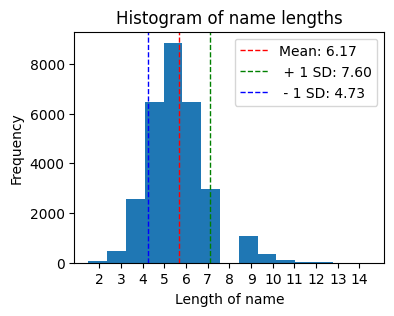

In [84]:
def plot_name_length_histogram(names, prefix=''):
    name_lengths = list(map(len, names))
    plt.hist(name_lengths, bins=max(name_lengths))
    # plt.yscale('log')
    plt.xticks(range(min(name_lengths), max(name_lengths)))
    plt.xlabel('Length of name')
    plt.ylabel('Frequency')
    plt.title(prefix+'Histogram of name lengths')

    mean_length = np.mean(name_lengths)
    std_dev_length = np.std(name_lengths)

    # Add mean and standard deviation lines
    plt.axvline(mean_length, color='r', linestyle='dashed', linewidth=1, label= f'Mean: {mean_length:.2f}')
    plt.axvline(mean_length + std_dev_length, color='g', linestyle='dashed', linewidth=1, label=f' + 1 SD: {mean_length + std_dev_length:.2f}')
    plt.axvline(mean_length - std_dev_length, color='b', linestyle='dashed', linewidth=1, label=f' - 1 SD: {mean_length - std_dev_length:.2f}')
    
    # move ticks positions under their bars
    position, lbls = plt.xticks()
    plt.xticks(position+.5, lbls)

    # Add a legend
    plt.legend()

plt.figure(figsize=(4, 3))
plot_name_length_histogram(data)

- Most names have a length between approx. 5 and 7. 
- Play with the scale of the y-axis to better visualize the borders.  

### Character distribution

- Before we build a "vocabulary" of our characters, we want to see which characters appear how many times. 
- We first concatenate all words and use the `Counter` class again to count the appearances of each character. 
- Create a barplot with the characters on the x-axis and their occurrence frequency on the y-axis.
- Note: We add different colors to each character by defining a colormap with `plt.cm.hsv`

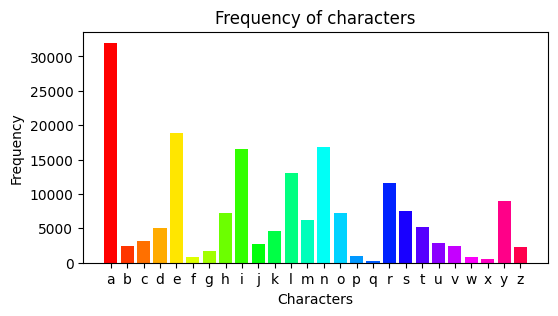

In [85]:
from collections import Counter

# Create a bar plot
def plot_char_frequency(names, prefix=''):
    # Count the frequency of each character
    char_counts = Counter(''.join(names))
    
    # Extract the keys and values from the Counter
    sorted_items = sorted(char_counts.items())
    
    # Extract the labels and values
    labels, counts = zip(*sorted_items)
    colors = plt.cm.hsv([i/len(labels) for i in range(len(labels))])

    plt.bar(labels, counts, color=colors)
    plt.xlabel('Characters')
    plt.ylabel('Frequency')
    plt.title(prefix+'Frequency of characters')
    
plt.figure(figsize=(6, 3))
plot_char_frequency(data)

- We recognize that `a`, `e`, `n`, `i`, `l`, `r`, and `y` are the most characters.
- Our language model will thus more likely use these charactes. 

## Building a vocabulary

- To build our language model, we must construct a "vocabulary" comprising all characters.
- This entails creating mappings between each character and its corresponding integer value.
- These mappings facilitate smooth interaction between our model and the dataset.

In [10]:
chars = sorted(list(set(''.join(data))))
stoi = {s:i+1 for i,s in enumerate(chars)} # mapping from characters to integers
stoi['.'] = 0 
itos = {i:s for s,i in stoi.items()} # mapping from integers to characters
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


**Note**: We added the character "." to use it as a placeholder for the beginning and the end of the names. Additionally, it is used to predict the end of the generated sequence.

## Building the datasets

We first need to define our **context length** (`block_size`), i.e., the number of characters considered for predicting the next character in the language model. 
    - Note this context length is fixed during the entire training. 

In [87]:
block_size = 3 # size of the block that supports the prediction.

- The dataset construction function takes in a list of strings and a block size as input.
- It generates two main components:
  - **Input data X** consisting of context windows of characters.
    - Each row represents a context window of characters, i.e., a *sample*.
    - Context windows are created by *sliding over each word* in the input list of strings.
    - Characters are represented as integer indices corresponding to their positions in the vocabulary (see above).
  - **Target data Y** consists of character indices immediately following the context windows.
    - Each index corresponds to the position of the character in the vocabulary.

In [12]:
def build_dataset(words: List[str], block_size: int, verbose: Optional[bool] = False) -> Tuple[np.ndarray, np.ndarray]:
    """
    Build a dataset for training a language model.

    Args:
        words (List[str]): List of strings containing names.
        block_size (int): Size of the context window.
        verbose (Optional[bool], optional): If True, print verbose output. Defaults to False.

    Returns:
        Tuple[np.ndarray, np.ndarray]: A tuple containing input data (X) and target data (Y) tensors.
    """
    X, Y = [], []

    for w in words:
        if verbose:
            print(f"\n{w}")
        
        context = [0] * block_size  # Initialize a context window of zeros
        for ch in w + '.':
            ix = stoi[ch]           # Convert character to integer index using stoi
            X.append(context)       # Append the current context window to X
            Y.append(ix)            # Append the index of the current character to Y
            if verbose:
                print(''.join(itos[i] for i in context), '--->', itos[ix])
            
            context = context[1:] + [ix] # Update the context window by cropping the first element and appending the new index.
    # Convert X and Y lists to PyTorch tensors
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

- Let's see how the dataset would look like for the first three names. 

In [91]:
X, Y = build_dataset(words=data, block_size=block_size, verbose=0)

- Note: We have created a dataset with `20` samples with the each input into the neural network having `block_size` integers and  1 target integer.

In [92]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([211328, 3]), torch.int64, torch.Size([211328]), torch.int64)

In [15]:
X, Y

(tensor([[ 0,  0,  0,  0],
         [ 0,  0,  0,  1],
         [ 0,  0,  1,  1],
         [ 0,  1,  1,  2],
         [ 1,  1,  2,  1],
         [ 1,  2,  1, 14],
         [ 0,  0,  0,  0],
         [ 0,  0,  0,  1],
         [ 0,  0,  1,  1],
         [ 0,  1,  1,  2],
         [ 1,  1,  2,  9],
         [ 1,  2,  9,  4],
         [ 0,  0,  0,  0],
         [ 0,  0,  0,  1],
         [ 0,  0,  1,  1],
         [ 0,  1,  1,  2],
         [ 1,  1,  2,  9],
         [ 1,  2,  9,  4],
         [ 2,  9,  4,  1],
         [ 9,  4,  1,  8]]),
 tensor([ 1,  1,  2,  1, 14,  0,  1,  1,  2,  9,  4,  0,  1,  1,  2,  9,  4,  1,
          8,  0]))

### Building training, validation and test datasets

- **Why Do We Need Them?**
    - Evaluation: We need to evaluate the performance of our machine learning model on data it hasn't seen before.
    - Generalization: We want our model to generalize well to new, unseen data, not just the data it was trained on.


|                      | **Definition**                                             | **Purpose**                                                 | **Size**                                                    |
|----------------------|-------------------------------------------------------------|-------------------------------------------------------------|--------------------------------------------------------------|
| **Training Set**     | The portion of the dataset used to *train the model*.         | Learning patterns and relationships.                        | Typically the largest portion of the dataset.               |
| **Validation Set**   | A subset used to *tune hyperparameters* and evaluate model performance. | Model selection and avoiding overfitting.                   | Smaller than training but larger than test set.             |
| **Test Set**         | The portion *held back from the model during training and validation*. | Evaluating the final model's performance on unseen data.         | Smaller than training and validation sets.                  |

- **Splitting the Dataset**
    - Randomization: The dataset is randomly divided into training, validation, and test sets to ensure unbiased evaluation.
    - Typical Split: Common splits include 60-20-20 or 70-15-15 for training, validation, and test sets, respectively.


- **Importance of Separation**
    - Avoiding Overfitting: Evaluating separate data helps prevent overfitting and ensures the model generalizes well to new data.
    - Model Selection: The validation set helps select the best model and fine-tuning hyperparameters.
    - Final Evaluation: The test set provides a final evaluation of the model's performance on unseen data.



- There are multiple ways to split a dataset: 
    1. implement it manually 
    2. use pre-implemented functions from machine learning Python packages, e.g., `scikit-learn`.

In [16]:
# define a seed for reproducability
seed = 1

In [93]:
# 1. implement it manually
random.seed(seed) # set random seed for reproducability
random.shuffle(data) # shuffle the data 
n1 = int(0.8*len(data))
n2 = int(0.9*len(data))

X_train, Y_train = build_dataset(data[:n1], block_size=block_size)
X_val, Y_val     = build_dataset(data[n1:n2], block_size=block_size)
X_test, Y_test   = build_dataset(data[n2:], block_size=block_size)

In [94]:
print(f"""
{X_train.shape=}\t{Y_train.shape=}
{X_val.shape=}\t{Y_val.shape=}
{X_test.shape=}\t{Y_test.shape=} 
""")


X_train.shape=torch.Size([168842, 3])	Y_train.shape=torch.Size([168842])
X_val.shape=torch.Size([21288, 3])	Y_val.shape=torch.Size([21288])
X_test.shape=torch.Size([21198, 3])	Y_test.shape=torch.Size([21198]) 



In [95]:
#2. use train_test_split from sklearn
from sklearn.model_selection import train_test_split

data_train, data_temp = train_test_split(data, train_size=0.8, shuffle=True, random_state=seed)
data_val, data_test   = train_test_split(data_temp, train_size=0.5, random_state=seed)

X_train, Y_train = build_dataset(data_train, block_size=block_size)
X_val, Y_val     = build_dataset(data_val, block_size=block_size)
X_test, Y_test   = build_dataset(data_test, block_size=block_size)

In [96]:
print(f"""
{X_train.shape=}\t{Y_train.shape=}
{X_val.shape=}\t{Y_val.shape=}
{X_test.shape=}\t{Y_test.shape=} 
""")


X_train.shape=torch.Size([168940, 3])	Y_train.shape=torch.Size([168940])
X_val.shape=torch.Size([21120, 3])	Y_val.shape=torch.Size([21120])
X_test.shape=torch.Size([21268, 3])	Y_test.shape=torch.Size([21268]) 



## Building the language model architecture

- As described above we need create the parameters $ \theta = (C, W^{(1)}, b^{(1)}, W^{(2)}, b^{(2)}) $ for the model optimization and initialize them randomly.
    - In the implementation, we use a different ordering of the dimensions for simplicity. 
Note: We use the `torch.Generator` class, which is an object responsible for generating random numbers. 
- We define the embedding dimension and nr. hidden layer neurons as follows:

In [97]:
embedding_dimension = 2
num_neurons_hidden_layer = 100
vocabulary_size = len(stoi)

In [22]:
def get_parameters(emb_dim: int, nneuros_h: int, set_requires_grad: bool = True) -> List[torch.Tensor]:
    """
    Generates a list of parameters for a neural network, including lookup table and two linear layers.

    Args:
        emb_dim (int): Dimension of the embedding vectors.
        nneuros_h (int): Number of neurons in the hidden layer.
        set_requires_grad (bool, optional): If True, sets requires_grad=True for all parameters. Default is True.

    Returns:
        List[torch.Tensor]: List of initialized parameters [C, W1, b1, W2, b2].
    """
    g = torch.Generator().manual_seed(seed)  # for reproducibility

    # Look up table
    C = torch.randn((vocabulary_size, emb_dim), generator=g)

    # First layer
    W1 = torch.randn((block_size * emb_dim, nneuros_h), generator=g)
    b1 = torch.randn(nneuros_h, generator=g)

    # Second layer
    W2 = torch.randn((nneuros_h, vocabulary_size), generator=g)
    b2 = torch.randn(vocabulary_size, generator=g)

    parameters = [C, W1, b1, W2, b2]
    if set_requires_grad:
        for p in parameters:
            p.requires_grad = True
    return parameters

In [98]:
parameters = get_parameters(embedding_dimension, num_neurons_hidden_layer, set_requires_grad=False)

C, W1, b1, W2, b2 = parameters

In [99]:
W1.shape

torch.Size([6, 100])

In [100]:
print(f"Number of total parameters: {sum(p.nelement() for p in parameters)}")

Number of total parameters: 3481


- Now, we want to ensure that the parameters will be changed during model training, i.e., backpropagation.
- For this, we need to set the `requires_gradient` parameter for each tensor in `parameters` to `True` so that gradients with respect to the parameters are computed. 

In [101]:
for p in parameters:
    p.requires_grad = True

- We additionally define the activation function of the hidden layer, i.e., `tanh` or `ReLU` 

In [26]:
activation_fun = torch.tanh
# activation_fun = torch.relu

## The forward pass

- The **forward pass** is a fundamental operation in neural networks, where input data is processed through the network's layers to produce an output.
- In our setting:
$$
f_{\theta}(x_i) = \text{softmax}\left(W^{(2)}\tanh\left(W^{(1)} C(\mathbf{x}_i) + b^{(1)}\right) + b^{(2)}\right)
$$
- where:
    - Block size length character index vector: $x_i \in \mathbb{N}^{n}$
    - $\mathbf{e}_i = C(x_i) \in \mathbb{R}^{d*n}$


- There is a missmatch of the dimension after embedding the samples and the weight matrix `W1`.

In [102]:
X_train.shape

torch.Size([168940, 3])

In [103]:
C.shape

torch.Size([27, 2])

In [104]:
emb_X_train = C[X_train]

emb_X_train.shape, W1.shape

(torch.Size([168940, 3, 2]), torch.Size([6, 100]))

- We want to use the efficient method [`torch.view`](https://pytorch.org/docs/stable/generated/torch.Tensor.view.html) to adapt the shape of the embedded characters. 
- Some properties of `view` 
    - The returned tensor shares the same data and must have the same number of elements but may have a different size.
    - Thus, the internal memory layout does not change; see [nice blog post for more information](http://blog.ezyang.com/2019/05/pytorch-internals/). 

In [106]:
emb_X_train.reshape(sn,n*d).shape

torch.Size([168940, 6])

In [107]:
sn, n, d = emb_X_train.shape
emb_X_train.view(sn,n*d).shape, W1.shape

(torch.Size([168940, 6]), torch.Size([6, 100]))

In [109]:
(emb_X_train.view(sn,n*d) @ W1 + b1).shape

torch.Size([168940, 100])

In [125]:
sn, n, d = emb_X_train.shape

embcat = emb_X_train.view(sn,n*d)
hpreact = embcat @ W1 + b1
h = activation_fun(hpreact)

- Now, we can write a full forward pass with the entire train dataset.
- **Computation graph**:
    - PyTorch constructs a computation graph dynamically during the forward pass.
    - This graph represents each operation (e.g., matrix multiplication, activation functions) as a node.
    - The graph tracks the operations and their dependencies, enabling automatic differentiation.
- After one forward pass, we get a probability distribution over the vocabulary for each context sample.

In [126]:
sn, n, d = emb_X_train.shape

embcat = emb_X_train.view(sn,n*d)
hpreact = embcat @ W1 + b1
h = activation_fun(hpreact)
logits = h @ W2 + b2
probas = F.softmax(logits, dim=1)

probas.shape, probas.sum(dim=1) 

(torch.Size([168940, 27]),
 tensor([1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
        grad_fn=<SumBackward1>))

### Sample names from the untrained model

In [127]:
def generate_name(parameters, block_size, random_generator=None, max_length=20):
    """
    Generates a name using the trained model.

    Args:
        parameters: List of parameters for the model.
        block_size: Size of the context window.
        random_generator: Random number generator.
    Returns:
        str: A generated name.
    """
    C, W1, b1, W2, b2 = parameters
    out = []
    context = [0] * block_size # initialize with all ...
    for _ in range(max_length):
        emb = C[torch.tensor([context])] # (1,block_size,d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=random_generator).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    return ''.join(itos[i] for i in out[:-1])

In [128]:
for _ in range(5):
    name = generate_name(parameters, block_size)
    print(name)

irlxqxegxmueirgxlge
vm
irgxlhueirge




### Computing the loss

- Having computed the probabilities for our train dataset, we can now compute the **cross-entropy loss** manually.
- How to get for each sample the probability of the target character?

In [129]:
probas[torch.arange(len(Y_train)), Y_train]

tensor([1.1928e-01, 8.8137e-07, 1.8576e-06,  ..., 2.0064e-04, 2.7489e-03,
        5.8219e-02], grad_fn=<IndexBackward0>)

In [130]:
probas[torch.arange(len(Y_train)), Y_train].shape

torch.Size([168940])

In [131]:
man_loss = - probas[torch.arange(len(Y_train)), Y_train].log().mean()
man_loss

tensor(13.6847, grad_fn=<NegBackward0>)

- The loss is high since we have not trained the model yet. 
- We will see how we minimize it.

- We can also compute the loss directly from the `logits` via the function `F.cross_entropy`
- Computes the same loss more efficiently (less tensors created) and numerically well behaved

In [132]:
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_train)
loss

tensor(13.6847, grad_fn=<NllLossBackward0>)

## The backward pass

- To optimize the parameters we need to do a backward pass. 
- We first set the gradients to zero and then  we call `loss.backward()`
    - When `loss.backward()` is called, PyTorch performs a backward pass through the computation graph.
    - It computes the gradients of the loss function with respect to each model parameter (i.e., weights and biases) using the chain rule of calculus.
    - These gradients indicate how much the loss would change with a small change in each parameter.
- We will also implement the backward computation manually!


In [133]:
# backward pass
for p in parameters:
    p.grad = None

In [134]:
loss.backward()

In [124]:
parameters[0].grad

- We define a learning rate and update the parameters

In [135]:
lr = 0.01

In [136]:
for p in parameters:
    p.data += -lr * p.grad

- If we compute the forward pass again we will see that the loss has changed

In [137]:
emb_X_train = C[X_train]
embcat = emb_X_train.view(sn,n*d)
hpreact = embcat @ W1 + b1
h = activation_fun(hpreact)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_train)
loss

tensor(13.5724, grad_fn=<NllLossBackward0>)

## Understanding Minibatches in Neural Network Training (optional)

- **Mini-Batch Gradient Descent** is a technique used to optimize the training of neural networks.
- **NOTE**: This lecture and homework 6 contain complementary information regarding the Gradient Descent (GD) algorithm. See homework 6 for more details on the mathematical formulation of GD.

| **Concept**                  | **Description**                                                                                                                                   |
|------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------|
| **Batch Gradient Descent**   | Uses **the entire dataset** to compute gradients. **Accurate but slow** and computationally expensive.                                                    |
| **Stochastic Gradient Descent (SGD)** | Uses **one data point** at a time to compute gradients. **Faster but can be noisy** and less stable.                                                       |
| **Minibatch Gradient Descent** | Processes **small batches of data** at a time. Combines benefits of both batch and stochastic gradient descent. Balances computational efficiency and gradient stability. |



-  **Mini batching Process**
   1. Divide the Dataset:
      - The dataset is split into smaller subsets called minibatches.
      - Each minibatch typically contains 16 to 128 samples.
      - Automatically done in PyTorch via the class called `DataLoader`. 

   2. Forward Pass for Each Minibatch:
      - Input data from the minibatch is passed through the network to compute predictions.

   3. Compute the Loss:
      - Loss is calculated using predictions and true labels for the minibatch.

   4. Backward Pass and Gradient Calculation:
      - Gradients of the loss with respect to model parameters are computed for each minibatch.

   5. Parameter Update:
      - Model parameters are updated using the gradients.
      - The update step is performed using an optimizer (e.g., SGD, Adam).

   6. Repeat for All Minibatches:
      - Process *repeats for all minibatches in the dataset*.
      - After all minibatches are processed, **one epoch of training is complete**.



- **Benefits of Mini batching**
   - Efficiency: Makes better use of computational resources.
   - Stability: Provides more stable gradient estimates than SGD.
   - Generalization: Helps model generalize better by introducing noise into training.


## Build the dataloaders

- Key Functions of `DataLoader` (PyTorch implementation of mini batching):
    - **Batching**: Automatically splits the dataset into batches of a specified size.
    - **Shuffling**: Randomly shuffles the data at the beginning of each epoch to ensure the model does not learn the order of the data.
    - **Parallelism**: Utilizes multiple worker processes to load data in parallel, speeding up data retrieval.
    - **Data Augmentation**: Can be combined with data transformations to augment the data on the fly.

- The `DataLoader` object requires a PyTorch `Dataset` object as input. 
- We can use the `TensorDataset` class to wrap tensors into a PyTorch `Dataset.`

In [41]:
batch_size = 64

In [138]:
# Create dataset and dataloader
train_dataset = torch.utils.data.TensorDataset(X_train, Y_train)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [139]:
# Create dataset and dataloader
val_dataset = torch.utils.data.TensorDataset(X_val, Y_val)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

## The full training loop

- We can now write the entire training loop using minibatching, the forward pass, loss computation, and the backward pass.
- Define the number of training steps we want to train and the learning rate. 
- (Reset all parameters, as we did an optimization step already)

In [140]:
parameters = get_parameters(embedding_dimension, num_neurons_hidden_layer, set_requires_grad=True)

C, W1, b1, W2, b2 = parameters

In [141]:
C.requires_grad

True

In [142]:
lossi = []
stepi = []

torch.manual_seed(seed) 

steps = 0
for epoch in range(epochs):
    pbar = tqdm(train_dataloader, desc=f"Training epoch {epoch}")
    for inputs, targets in pbar:
        # -------------------------------------------------------------
        # Forward pass
        # -------------------------------------------------------------
        emb = C[inputs]
        sn, n, d = emb.shape
        embcat = emb.view(sn, n * d)

        # Linear layer
        hpreact = embcat @ W1 + b1  # hidden layer pre-activation

        h = torch.tanh(hpreact)  # hidden layer
        logits = h @ W2 + b2  # output layer
        loss = F.cross_entropy(logits, targets)  # loss function
        
        # -------------------------------------------------------------
        # Backward pass: automatic backprop
        # -------------------------------------------------------------
        for p in parameters:
            p.grad = None
            
        loss.backward() # this is not needed as we are computing the gradients manually
        
        # -------------------------------------------------------------
        # Update gradients
        # -------------------------------------------------------------
        for p in parameters:
            p.data += -lr * p.grad

        # print statements
        # if steps % 2000 == 0:  # print every once in a while
        #     print(f'{steps:7d}/{len(train_dataloader.dataset) * epochs // sn:7d}: {loss.item():.4f}')
        pbar.set_postfix({'loss': loss.item()})

        # track statistics
        stepi.append(steps)
        lossi.append(loss.item())

        steps +=1

Training epoch 0:   0%|          | 0/2640 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/2640 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/2640 [00:00<?, ?it/s]

In [143]:
# training loss
emb = C[X_train]
sn, n, d = emb.shape
emb = emb.view(sn,n*d)

h = activation_fun(emb @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_train)
loss

tensor(2.6092, grad_fn=<NllLossBackward0>)

Text(0.5, 1.0, 'Loss curve during training')

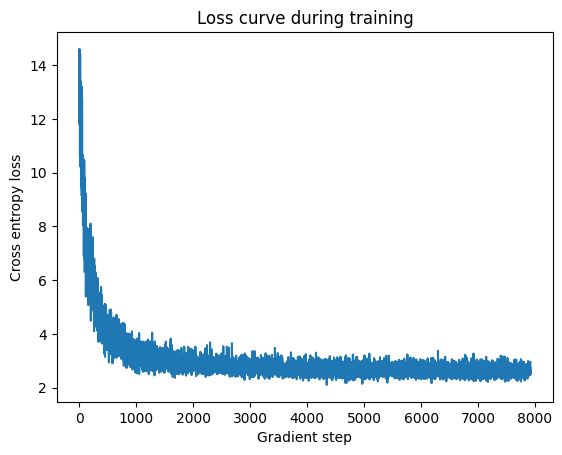

In [144]:
plt.plot(stepi, lossi)
plt.xlabel("Gradient step")
plt.ylabel("Cross entropy loss")
plt.title("Loss curve during training")

## How to determine the learning rate?  (optional)

### Determine initial learning rate with a series of short training runs

- Let's simplify the training loop. 
    - For each iteration, we only take one minibatch. 
- We aim to see if there is a range of learning rates that suits our optimization problem well 

In [53]:
parameters = get_parameters(embedding_dimension, num_neurons_hidden_layer, set_requires_grad=True)

C, W1, b1, W2, b2 = parameters

- Let's see how our loss looks like if we start with really small learning rates (`1e-3`) and increase them exponentially to (`1`).

In [54]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre  

In [55]:
lri = []
lossi = []

torch.manual_seed(1) 

for i in tqdm(range(1000), desc="Training steps"):
    
    idx = torch.randint(0, X_train.shape[0], (batch_size,))
    inputs, targets = train_dataset[idx]
    
    # forward path
    emb = C[inputs]
    sn, n, d = emb.shape
    emb = emb.view(sn,n*d)

    h = activation_fun(emb @ W1 + b1)
    logits = h @ W2 + b2

    # loss computation 
    loss = F.cross_entropy(logits, targets)

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # gradient update
    lr = lrs[i]
    for p in parameters:
      p.data += -lr * p.grad

    # track statistics
    lri.append(lre[i])
    lossi.append(loss.item())

Training steps:   0%|          | 0/1000 [00:00<?, ?it/s]

- We can observe that good learning rates are around `10**(-1) = 0.1`.
- Below the learning rates are simply too small.
- Above we have too large learning rates. 

Text(0, 0.5, 'Cross entropy loss')

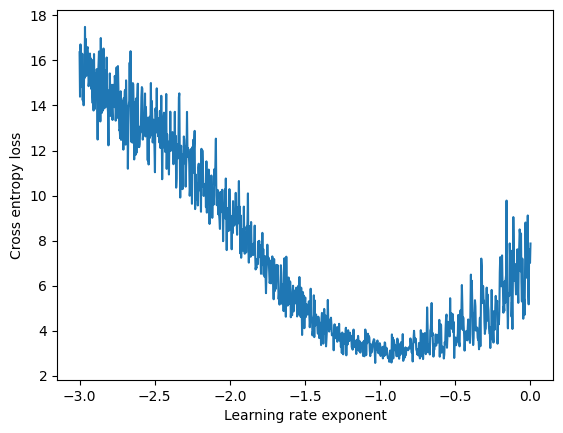

In [56]:
plt.plot(lri, lossi)
plt.xlabel("Learning rate exponent")
plt.ylabel("Cross entropy loss")

### Learning rate decay

- **Adaptive Learning Rates**: While a fixed learning rate may work well initially, it may lead to suboptimal performance as training progresses. Learning rate decay adapts the learning rate dynamically during training to improve optimization performance.
- There are many standard optimization algorithms, see a [list on the PyTorch documentation website](https://pytorch.org/docs/stable/optim.html).
- For now, we will start with our found learning rate and reduce it when it reaches a threshold in terms of total gradient update steps: `lr = 0.1 if steps < 10000 else 0.01`. 

In [57]:
# Reset the network
parameters = get_parameters(embedding_dimension, num_neurons_hidden_layer, set_requires_grad=True)

C, W1, b1, W2, b2 = parameters

epochs = 3

- We now the define the training loop in a method such that we can access it later on. 

In [58]:
def train_loop(use_tqdm:bool = True):
    lossi = []
    stepi = []

    steps = 0

    torch.manual_seed(seed)

    for epoch in range(epochs):
        looping_iterator = tqdm(train_dataloader, desc=f"Training epoch {epoch}") if use_tqdm else train_dataloader
        for inputs, targets in looping_iterator:
            # forward path
            emb = C[inputs]
            sn, n, d = emb.shape
            emb = emb.view(sn,n*d)

            h = activation_fun(emb @ W1 + b1)
            logits = h @ W2 + b2

            # loss computation 
            loss = F.cross_entropy(logits, targets)

            # backward pass
            for p in parameters:
                p.grad = None
            loss.backward()

            # gradient update
            lr = 0.1 if steps < 10000 else 0.01
            for p in parameters:
                p.data += -lr * p.grad

            # track statistics
            stepi.append(steps)
            lossi.append(loss.item())

            steps +=1
    return lossi, stepi

In [59]:
lossi, stepi = train_loop()

Training epoch 0:   0%|          | 0/2640 [00:00<?, ?it/s]

Training epoch 1:   0%|          | 0/2640 [00:00<?, ?it/s]

Training epoch 2:   0%|          | 0/2640 [00:00<?, ?it/s]

In [60]:
# training loss
emb = C[X_train]
sn, n, d = emb.shape
emb = emb.view(sn,n*d)

h = activation_fun(emb @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_train)
train_loss = loss.clone().detach()
loss

tensor(2.5012, grad_fn=<NllLossBackward0>)

Text(0.5, 1.0, 'Loss curve during training')

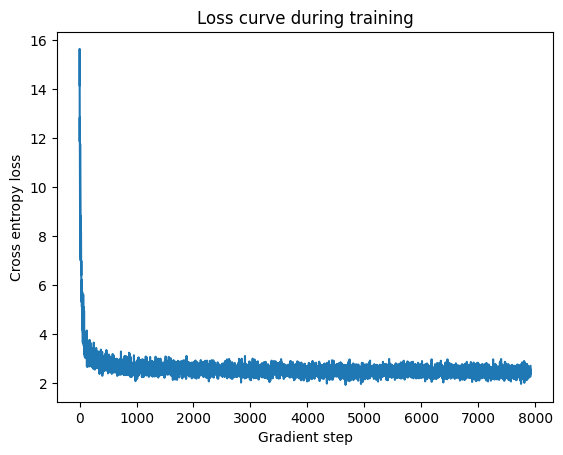

In [61]:
plt.plot(stepi, lossi)
plt.xlabel("Gradient step")
plt.ylabel("Cross entropy loss")
plt.title("Loss curve during training")

## Is our language model overfitting on the training data?

- Definition: **Overfitting** is when a model learns the training data too well, including noise and outliers, which negatively impacts performance on new, unseen data.
    - **Training Data Memorization**: The model memorizes the training data rather than learning general patterns.
    - **Poor Generalization**: The model performs well on the training data but poorly on validation or test data.

- **Symptoms of Overfitting**
    - **Low Training Error, High Validation Error**: The model achieves very low error on the training data but has a high error on the validation data.
    - **Complex Decision Boundaries**: In classification problems, overfitting can lead to overly complex decision boundaries that don't generalize well to new data.

- How well is our current model with the given hyperparameter setting ($d=2$, $k=100$) performing?
- We see that the validation loss is close to the training loss. Thus, we are not overfitting but rather underfitting.  
    - Note: our model is not powerful enough to purely memorize the data.

In [145]:
# validation loss
emb = C[X_val]
sn, n, d = emb.shape
emb = emb.view(sn,n*d)

h = activation_fun(emb @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_val)
print(f"Train loss: {train_loss:.4f}")
print(f"Validation loss: {loss:.4f}")

Train loss: 2.5012
Validation loss: 2.6157


## Tuning our hyper-parameters with the validation set

- To find the best hyper-parameter configuration we can train our language model on the training set with different hyper-parameter settings.
- For each setting, compute the loss on the validation set. 
- In this example, we use a simple exhaustive grid search approach. However, there are also randomized and other approaches. 
    - Find more information on the following [website](https://scikit-learn.org/stable/modules/grid_search.html).

In [146]:
from itertools import product

embed_dims = [2, 4, 6, 8, 10]
hl_depths = [100, 200, 300]

combinations = list(product(embed_dims, hl_depths))

losses = []

epochs = 3

for i, (emb_dim, hl_depth)in tqdm(enumerate(combinations)):
    parameters = get_parameters(emb_dim, hl_depth, set_requires_grad=True)
    C, W1, b1, W2, b2 = parameters

    _, _ = train_loop(use_tqdm=False)

    # Compute validation loss
    emb = C[X_val]
    sn, n, d = emb.shape
    emb = emb.view(sn,n*d)

    h = activation_fun(emb @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y_val)

    losses.append((i, loss.item()))

0it [00:00, ?it/s]

- See the achieved validation losses for the different configurations. 
- Note how validation losses are smaller for larger character embedding sizes.

In [147]:
sorted_losses = sorted(losses, key= lambda x: x[1])
print('Validation losses for different combinations:')
[ (idx, combinations[idx], loss)for idx, loss in sorted_losses]

Validation losses for different combinations:


[(12, (10, 100), 2.389131546020508),
 (9, (8, 100), 2.4024243354797363),
 (3, (4, 100), 2.4512343406677246),
 (6, (6, 100), 2.453592538833618),
 (0, (2, 100), 2.503309726715088),
 (10, (8, 200), 2.530355453491211),
 (13, (10, 200), 2.5487613677978516),
 (4, (4, 200), 2.6298019886016846),
 (7, (6, 200), 2.666311025619507),
 (1, (2, 200), 2.668114423751831),
 (14, (10, 300), 2.696398973464966),
 (2, (2, 300), 2.8292934894561768),
 (8, (6, 300), 2.834285020828247),
 (11, (8, 300), 2.8957765102386475),
 (5, (4, 300), 3.113377809524536)]

- Let's get the configuration that achieved lowest validation error. 

In [148]:
best_config = sorted_losses[0]
best_emb_dim, best_hl_depth = combinations[best_config[0]]
print(f"The configuration with smallest validation loss ({best_config[1]:.4f}) " 
      f"has embedding dimension {best_emb_dim} and {best_hl_depth} " 
      f"neurons in the hidden layer.")

The configuration with smallest validation loss (2.3891) has embedding dimension 10 and 100 neurons in the hidden layer.


## Visualize the embedding vectors of the characters

### Visualizing the embeddings if embedding dimension == 2

- We will train a model on 2 embedding dimensions and display the characters in the embedding space. 

In [149]:
parameters = get_parameters(2, best_hl_depth, set_requires_grad=True)
C, W1, b1, W2, b2 = parameters

C_pretrain = C.clone().detach()

_, _ = train_loop(use_tqdm=False)

C.shape, (C_pretrain==C).any() # See that C has changed during training

(torch.Size([27, 2]), tensor(False))

- The learned embeddings cluster the characters into sensible groups.
    - The vowels all group together
    - All characters that are far away from the rest are special characters: rare, special behavior.

Text(0.5, 1.0, 'Character Embedding Space')

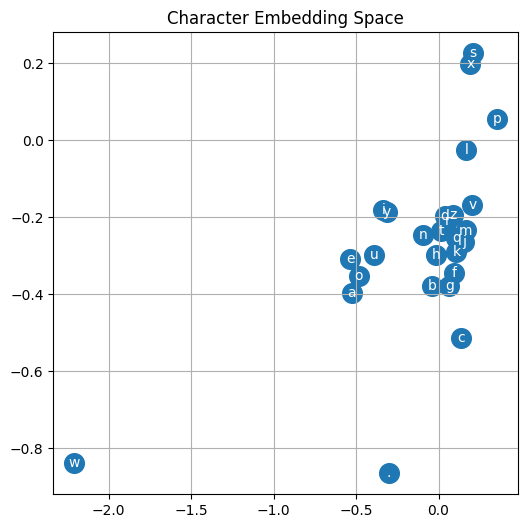

In [150]:
plt.figure(figsize=(6,6))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')
plt.title('Character Embedding Space')

### Visualizing the PCA of the embeddings if embedding dimension > 2 (optional)

- In the previous section, we found the embedding dimension > 2 that achieves the best validation performance.
- Since we cannot easily visualize more than three dimensions, we first reduce the dimension via Principle Component Analysis (PCA) (introduced later in the course) and visualize the two principal components. 

In [152]:
parameters = get_parameters(best_emb_dim, best_hl_depth, set_requires_grad=True)
C, W1, b1, W2, b2 = parameters

_, _ = train_loop(use_tqdm=False)

C.shape

torch.Size([27, 10])

In [153]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [154]:
C_std = StandardScaler().fit_transform(C.detach().numpy())
C_PCA = PCA(n_components=2).fit_transform(C_std)

- The learned embeddings cluster the characters into sensible groups.
    - Most vowels group together
    - All characters that are far away from the rest are special characters: rare, special behavior (`.`)
- It now has – as we are using a higher and better embedding dimension – the freedom to represent the characters and compute on top of them more powerfully.

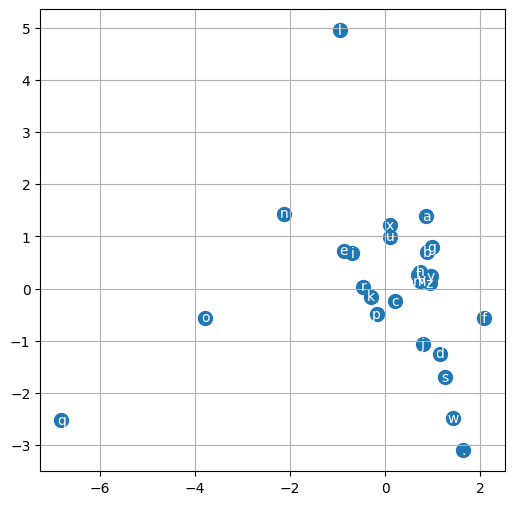

In [155]:
plt.figure(figsize=(6,6))
plt.scatter(C_PCA[:,0], C_PCA[:,1], s=100)
for i in range(C_PCA.shape[0]):
    plt.text(C_PCA[i,0], C_PCA[i,1], itos[i], ha="center", va="center", color='white')
plt.grid('minor')

## Almost at the end: final performance estimate with test set and sampling new names from the model. 

- Let's see the test set performance.
- **Note**: In practice, one would 
    1. concatenate the train and validation dataset after the final model selection 
    2. retrain the model on the concatenated dataset
    3. do final performance estimation on the test set (*!! Keep in mind, we only touch the test set in the end, never before!!*)

In [156]:
# Compute validation loss
emb = C[X_test]
sn, n, d = emb.shape
emb = emb.view(sn,n*d)

h = activation_fun(emb @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y_test)

print("Final evaluation:")
print(f"- Train loss: {best_config[1]:.4f}")
print(f"- Test  loss: {loss:.4f}")


Final evaluation:
- Train loss: 2.3891
- Test  loss: 2.3819


- Let's sample 20 new names. 

In [157]:
g = torch.Generator().manual_seed(seed + 50)
new_names = []
parameters = C, W1, b1, W2, b2
for _ in range(20):
    new_names.append(generate_name(parameters, block_size, g))
    print(new_names[-1])

iegheon
azaimelin
tay
aza
bena
rozalah
jozkinna
iimannidario
netmion
kakmena
nakdiletteleann
shon
mivig
ezmien
jyva
rvalaie
frily
valyn
kakrelyni
khatlitelloah


### Compare statistics of generated names and dataset

- Generate a large set of names with the model.

In [158]:
g = torch.Generator().manual_seed(seed + 50)
new_names = []
parameters = C, W1, b1, W2, b2
for _ in range(1000):
    new_names.append(generate_name(parameters, block_size, g))

- The length and character distributions match (roughly) with the statistics of the dataset!
- Note: The mean name length is correct but the model struggles to terminate some names because of the short context window.

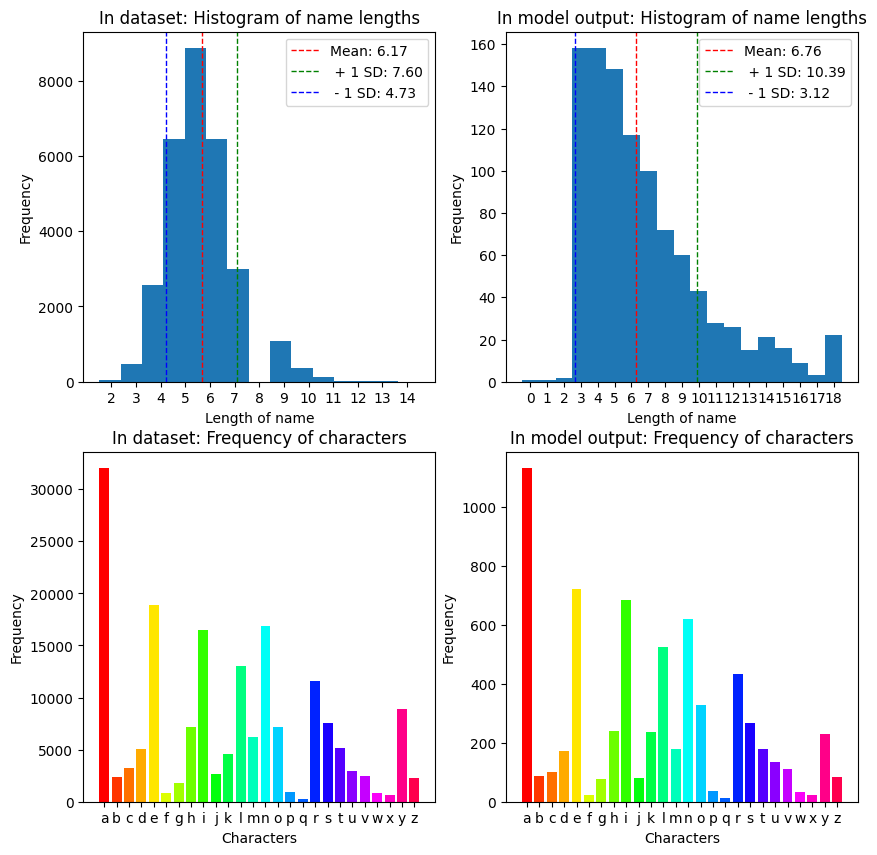

In [159]:
# replicate the above cell using the functions

fig = plt.figure(figsize=(10,10))

plt.subplot(2,2,1)
plot_name_length_histogram(data, prefix='In dataset: ')

plt.subplot(2,2,2)
plot_name_length_histogram(new_names, prefix='In model output: ')

plt.subplot(2,2,3)
plot_char_frequency(data, prefix='In dataset: ')

plt.subplot(2,2,4)
plot_char_frequency(new_names, prefix='In model output: ')


In [77]:
len(new_names), len(data)

(1000, 29494)

$$\textbf{Thank you for your attention.}$$